In [41]:
import sys

sys.path.append("../..")

In [42]:
# import the modules and functions
import torch
from pann_net import PANN, EulerCell_Buck
import numpy as np
from pann_utils import duty_cycle_mod
from torch import nn
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# define circuit parameters and network variables
L, Co, Ro = 50e-6, 1000e-6, 3
Ts = 1 / 20e3
Tslen = 100
dt = Ts / Tslen

buck_Euler_cell = torch.jit.script(
    EulerCell_Buck(dt, L, Co, Ro)
)  # define the Euler cell for DAB
pann_buck = torch.jit.script(PANN(buck_Euler_cell))  # define the PANN for DAB
print(pann_buck)

RecursiveScriptModule(
  original_name=PANN
  (cell): RecursiveScriptModule(original_name=EulerCell_Buck)
)


In [43]:
# 日本語フォント
font_path = "/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

## 学習データの生成

PANNの学習用データを生成します。異なるデューティ比、入力電圧、回路パラメータで複数のシミュレーションを実行します。

In [44]:
# 学習データ生成関数
def generate_training_data(n_samples=100, Tsim_per_sample=50):
    """
    異なる条件でBuckコンバータのシミュレーションを実行し、学習データを生成

    Parameters:
    - n_samples: 生成するサンプル数
    - Tsim_per_sample: 各サンプルのシミュレーション周期数
    """

    # データ格納用リスト
    all_inputs = []
    all_states = []

    # パラメータの範囲を定義
    duty_range = (0.15, 0.35)  # デューティ比の範囲
    vin_range = (24, 32)  # 入力電圧の範囲 [V]

    for i in range(n_samples):
        # ランダムにパラメータを選択
        D0_sample = np.random.uniform(*duty_range)
        Vin_sample = np.random.uniform(*vin_range)

        # シミュレーション時間
        Tsim_sample = Tsim_per_sample * Ts

        # 入力電圧波形を生成
        vp_sample = duty_cycle_mod(D0_sample, Vin_sample, dt, Tsim_sample, Ts)

        # PANNで状態を計算
        inputs_sample = torch.FloatTensor(vp_sample[None, :, None])
        state0_sample = torch.zeros((1, 1, 2))

        with torch.no_grad():
            states_sample = pann_buck(inputs_sample, state0_sample)

        # numpy配列に変換して保存
        all_inputs.append(inputs_sample.squeeze().numpy())
        all_states.append(states_sample.squeeze().numpy())

    # リストをnumpy配列に変換
    all_inputs = np.array(all_inputs)
    all_states = np.array(all_states)

    print(f"生成したデータ形状:")
    print(f"  入力: {all_inputs.shape}")
    print(f"  状態: {all_states.shape}")

    return all_inputs, all_states

# 学習データを生成
print("学習データを生成中...")
train_data_inputs, train_data_states = generate_training_data(n_samples=50, Tsim_per_sample=20)

学習データを生成中...
生成したデータ形状:
  入力: (50, 2000)
  状態: (50, 2000, 2)


## データセットクラスとデータローダーの準備

In [45]:
# Datasetクラスの定義
from torch.utils.data import Dataset, DataLoader

class BuckDataset(Dataset):
    """Buckコンバータの学習用データセット"""
    def __init__(self, states_prev, inputs, states_next):
        """
        Args:
            states_prev: 前の時刻の状態 [batch, time, state_dim]
            inputs: 入力電圧 [batch, time, input_dim]
            states_next: 次の時刻の状態（ターゲット） [batch, time, state_dim]
        """
        self.states_prev = states_prev
        self.inputs = inputs
        self.states_next = states_next

    def __len__(self):
        return self.states_prev.shape[0] * self.states_prev.shape[1]

    def __getitem__(self, idx):
        batch_idx = idx // self.states_prev.shape[1]
        time_idx = idx % self.states_prev.shape[1]

        return (
            self.states_prev[batch_idx, time_idx],
            self.inputs[batch_idx, time_idx],
            self.states_next[batch_idx, time_idx]
        )

# データの分割（train/val/test）
def split_data(inputs, states, train_ratio=0.6, val_ratio=0.2):
    """データをtrain/val/testに分割"""
    n_samples = inputs.shape[0]
    n_train = int(n_samples * train_ratio)
    n_val = int(n_samples * val_ratio)

    # インデックスをシャッフル
    np.random.seed(42)
    indices = np.random.permutation(n_samples)

    # データを分割
    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train+n_val]
    test_idx = indices[n_train+n_val:]

    return (
        inputs[train_idx], states[train_idx],
        inputs[val_idx], states[val_idx],
        inputs[test_idx], states[test_idx]
    )

# データを分割
train_inputs, train_states, val_inputs, val_states, test_inputs, test_states = split_data(
    train_data_inputs[:, :, None],  # 入力に次元追加
    train_data_states
)

print(f"データセット形状:")
print(f"  Train: 入力 {train_inputs.shape}, 状態 {train_states.shape}")
print(f"  Val: 入力 {val_inputs.shape}, 状態 {val_states.shape}")
print(f"  Test: 入力 {test_inputs.shape}, 状態 {test_states.shape}")

データセット形状:
  Train: 入力 (30, 2000, 1), 状態 (30, 2000, 2)
  Val: 入力 (10, 2000, 1), 状態 (10, 2000, 2)
  Test: 入力 (10, 2000, 1), 状態 (10, 2000, 2)


In [46]:
# Tensorに変換してDataLoaderを作成
train_inputs_t = torch.FloatTensor(train_inputs)
train_states_t = torch.FloatTensor(train_states)
val_inputs_t = torch.FloatTensor(val_inputs)
val_states_t = torch.FloatTensor(val_states)
test_inputs_t = torch.FloatTensor(test_inputs)
test_states_t = torch.FloatTensor(test_states)

# DataLoaderの作成（時系列のため、前の状態と次の状態をペアで）
train_dataset = BuckDataset(
    train_states_t[:, :-1],  # 前の時刻の状態
    train_inputs_t[:, 1:],   # 入力
    train_states_t[:, 1:]    # 次の時刻の状態（ターゲット）
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=False
)

print(f"DataLoader準備完了: バッチサイズ=128, バッチ数={len(train_loader)}")

DataLoader準備完了: バッチサイズ=128, バッチ数=469


## PANNモデルの学習

回路パラメータを推定するために、PANNを学習します。

In [47]:
# 学習用PANNの初期化（パラメータを意図的にずらす）
L_init = 100e-6  # 真値: 10e-6
Co_init = 47e-6  # 真値: 1000e-6
Ro_init = 10  # 真値: 3

# 新しいPANNインスタンスを作成
buck_cell_train = EulerCell_Buck(dt, L_init, Co_init, Ro_init)
pann_buck_train = PANN(buck_cell_train)

# オプティマイザの設定
optimizer = torch.optim.Adam(
    [
        {"params": [pann_buck_train.cell.L], "lr": 2e-6},
        {"params": [pann_buck_train.cell.Co], "lr": 1e-1},
        {"params": [pann_buck_train.cell.Ro], "lr": 5e-1},
    ]
)

# 損失関数
criterion = nn.MSELoss()

print(f"初期パラメータ:")
print(f"  L: {pann_buck_train.cell.L.item():.2e} H (真値: {L:.2e} H)")
print(f"  Co: {pann_buck_train.cell.Co.item():.2e} F (真値: {Co:.2e} F)")
print(f"  Ro: {pann_buck_train.cell.Ro.item():.2f} Ω (真値: {Ro:.1f} Ω)")

初期パラメータ:
  L: 1.00e-04 H (真値: 5.00e-05 H)
  Co: 4.70e-05 F (真値: 1.00e-03 F)
  Ro: 10.00 Ω (真値: 3.0 Ω)


In [48]:
# 学習ループ
def train_pann(model, train_loader, val_inputs, val_states, optimizer, criterion, n_epochs=100):
    """PANNを学習する関数"""

    train_losses = []
    val_losses = []
    param_history = []

    for epoch in range(n_epochs):
        # Training
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for batch in train_loader:
            state_prev, inputs, state_target = batch

            # 勾配をリセット
            optimizer.zero_grad()

            # 予測
            state_pred = model.cell(inputs, state_prev)

            # 損失計算
            loss = criterion(state_pred, state_target)

            # バックプロパゲーション
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            # 検証データで推論
            val_states_pred = model(val_inputs, torch.zeros((val_inputs.shape[0], 1, 2)))
            val_loss = criterion(val_states_pred, val_states).item()
            val_losses.append(val_loss)

            # パラメータを記録
            param_history.append([
                model.cell.L.item(),
                model.cell.Co.item(),
                model.cell.Ro.item()
            ])

        # 10エポックごとに進捗表示
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}")
            print(f"  Train Loss: {avg_train_loss:.6f}")
            print(f"  Val Loss: {val_loss:.6f}")
            print(f"  L: {model.cell.L.item():.2e}, Co: {model.cell.Co.item():.2e}, Ro: {model.cell.Ro.item():.2f}")
            print("-" * 50)

    return train_losses, val_losses, param_history

# 学習を実行
print("学習を開始します...")
train_losses, val_losses, param_history = train_pann(
    pann_buck_train,
    train_loader,
    val_inputs_t,
    val_states_t,
    optimizer,
    criterion,
    n_epochs=100
)

学習を開始します...
Epoch 10/100
  Train Loss: 0.000037
  Val Loss: 3762.844727
  L: 5.00e-05, Co: 6.01e-01, Ro: 8.38
--------------------------------------------------
Epoch 20/100
  Train Loss: 0.000037
  Val Loss: 3762.837646
  L: 5.00e-05, Co: 6.00e-01, Ro: 14.33
--------------------------------------------------
Epoch 30/100
  Train Loss: 0.000037
  Val Loss: 3762.752686
  L: 5.00e-05, Co: 5.99e-01, Ro: 24.05
--------------------------------------------------
Epoch 40/100
  Train Loss: 0.000037
  Val Loss: 3761.784424
  L: 5.00e-05, Co: 5.79e-01, Ro: 32.10
--------------------------------------------------
Epoch 50/100
  Train Loss: 0.000037
  Val Loss: 3825.857178
  L: 5.00e-05, Co: -4.84e-01, Ro: 38.82
--------------------------------------------------
Epoch 60/100
  Train Loss: 0.000037
  Val Loss: 3803.510010
  L: 5.00e-05, Co: -1.34e+00, Ro: 35.07
--------------------------------------------------
Epoch 70/100
  Train Loss: 0.000037
  Val Loss: 3796.562500
  L: 5.00e-05, Co: -2.97e+0

In [49]:
# 最終的なパラメータを表示
print("\n学習完了!")
print(f"最終パラメータ:")
print(f"  L: {pann_buck_train.cell.L.item():.2e} H (真値: {L:.2e} H)")
print(f"  Co: {pann_buck_train.cell.Co.item():.2e} F (真値: {Co:.2e} F)")
print(f"  Ro: {pann_buck_train.cell.Ro.item():.2f} Ω (真値: {Ro:.1f} Ω)")

# 相対誤差を計算
L_error = abs(pann_buck_train.cell.L.item() - L) / L * 100
Co_error = abs(pann_buck_train.cell.Co.item() - Co) / Co * 100
Ro_error = abs(pann_buck_train.cell.Ro.item() - Ro) / Ro * 100

print(f"\n相対誤差:")
print(f"  L: {L_error:.2f}%")
print(f"  Co: {Co_error:.2f}%")
print(f"  Ro: {Ro_error:.2f}%")


学習完了!
最終パラメータ:
  L: 5.00e-05 H (真値: 5.00e-05 H)
  Co: -2.12e+01 F (真値: 1.00e-03 F)
  Ro: 31.63 Ω (真値: 3.0 Ω)

相対誤差:
  L: 0.00%
  Co: 2117130.14%
  Ro: 954.33%


## 学習結果の可視化

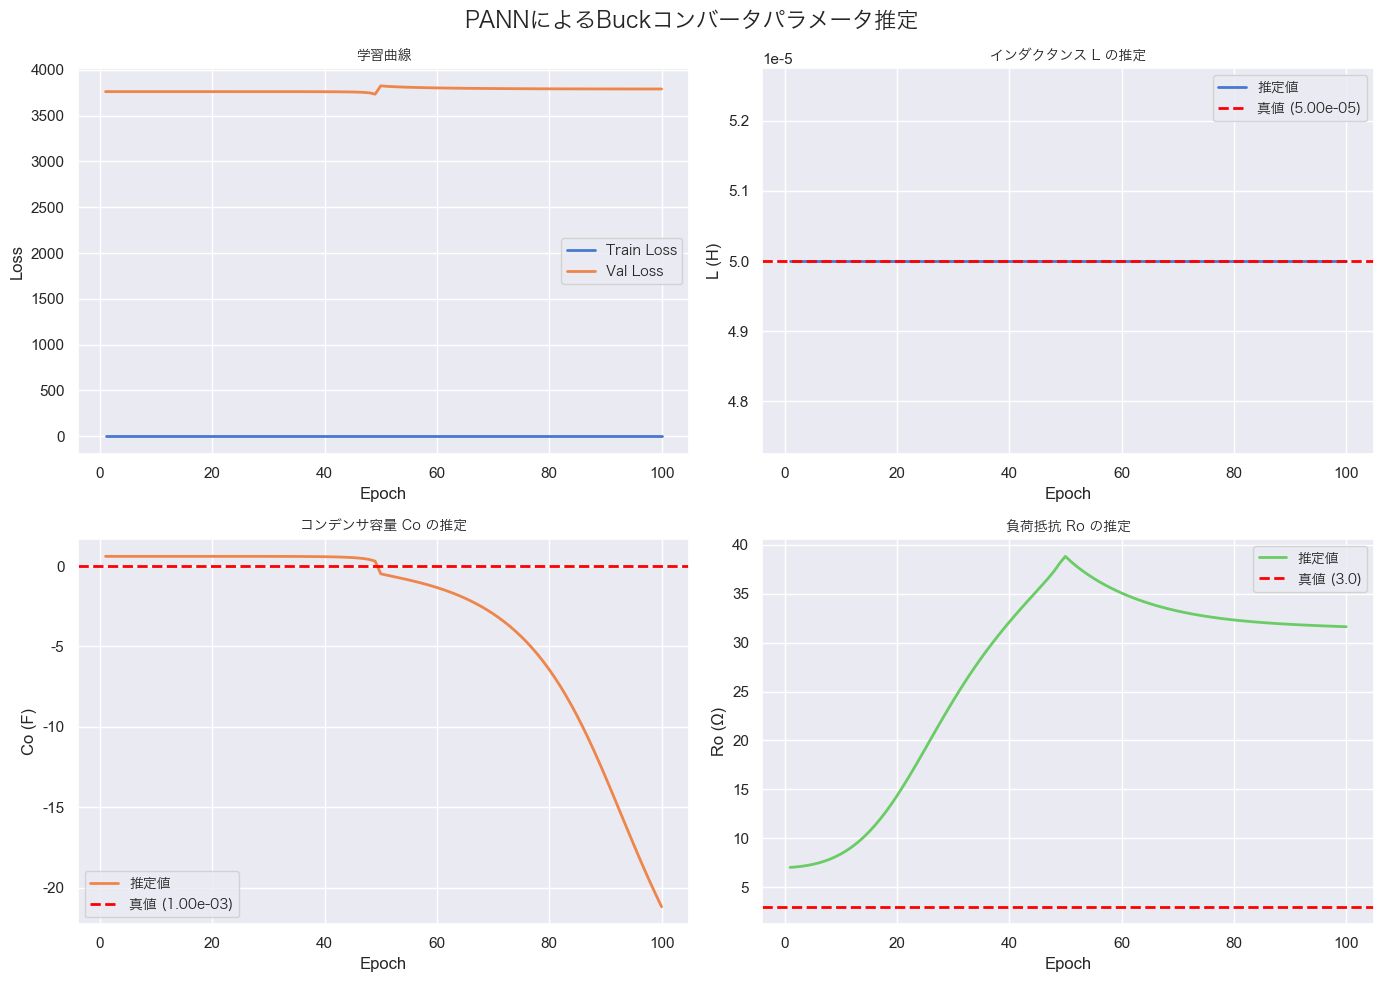

In [50]:
# 学習曲線とパラメータ推定の可視化
sns.set_theme(style="darkgrid")

# 4つのサブプロットを作成
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# エポック数
epochs = np.arange(1, len(train_losses) + 1)
param_history = np.array(param_history)

# プロット1: 損失曲線
ax1.plot(epochs, train_losses, label="Train Loss", linewidth=2, color=sns.color_palette("muted")[0])
ax1.plot(epochs, val_losses, label="Val Loss", linewidth=2, color=sns.color_palette("muted")[1])
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.set_title("学習曲線", fontsize=14, weight="bold", fontproperties=font_prop)
ax1.legend(prop=font_prop)
ax1.grid(True)

# プロット2: インダクタンス L の推定
ax2.plot(epochs, param_history[:, 0], label="推定値", linewidth=2, color=sns.color_palette("muted")[0])
ax2.axhline(y=L, color='red', linestyle='--', label=f"真値 ({L:.2e})", linewidth=2)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("L (H)", fontsize=12)
ax2.set_title("インダクタンス L の推定", fontsize=14, weight="bold", fontproperties=font_prop)
ax2.legend(prop=font_prop)
ax2.grid(True)

# プロット3: コンデンサ容量 Co の推定
ax3.plot(epochs, param_history[:, 1], label="推定値", linewidth=2, color=sns.color_palette("muted")[1])
ax3.axhline(y=Co, color='red', linestyle='--', label=f"真値 ({Co:.2e})", linewidth=2)
ax3.set_xlabel("Epoch", fontsize=12)
ax3.set_ylabel("Co (F)", fontsize=12)
ax3.set_title("コンデンサ容量 Co の推定", fontsize=14, weight="bold", fontproperties=font_prop)
ax3.legend(prop=font_prop)
ax3.grid(True)

# プロット4: 負荷抵抗 Ro の推定
ax4.plot(epochs, param_history[:, 2], label="推定値", linewidth=2, color=sns.color_palette("muted")[2])
ax4.axhline(y=Ro, color='red', linestyle='--', label=f"真値 ({Ro:.1f})", linewidth=2)
ax4.set_xlabel("Epoch", fontsize=12)
ax4.set_ylabel("Ro (Ω)", fontsize=12)
ax4.set_title("負荷抵抗 Ro の推定", fontsize=14, weight="bold", fontproperties=font_prop)
ax4.legend(prop=font_prop)
ax4.grid(True)

plt.suptitle("PANNによるBuckコンバータパラメータ推定", fontsize=16, weight="bold", fontproperties=font_prop)
plt.tight_layout()
plt.show()

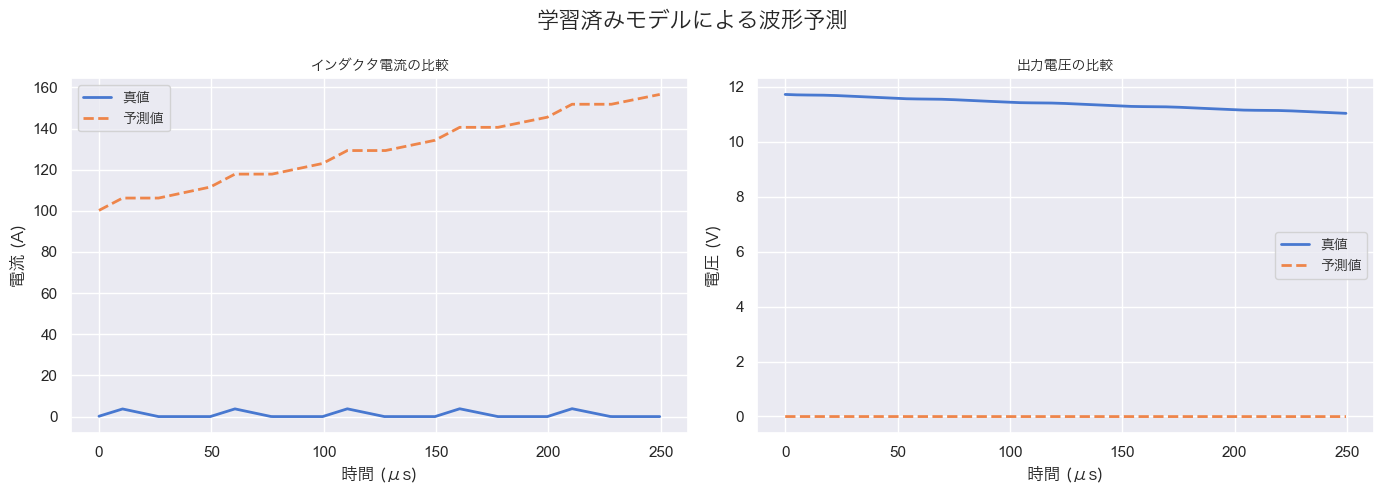

インダクタ電流 MSE: 5684.242676
出力電圧 MSE: 79.664688


In [51]:
# 予測波形と真値の比較
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# テストデータから1サンプルを選択
test_idx = 0
test_input = test_inputs_t[test_idx:test_idx+1]
test_state = test_states_t[test_idx:test_idx+1]

# 学習済みモデルで予測
pann_buck_train.eval()
with torch.no_grad():
    pred_state = pann_buck_train(test_input, torch.zeros((1, 1, 2)))

# numpy配列に変換
test_input_np = test_input.squeeze().numpy()
test_state_np = test_state.squeeze().numpy()
pred_state_np = pred_state.squeeze().numpy()

# 時間軸（最後の5周期分）
n_points = 5 * Tslen
t_plot = np.arange(n_points) * dt * 1e6

# プロット1: インダクタ電流
ax1.plot(t_plot, test_state_np[-n_points:, 0], label="真値", linewidth=2,
         color=sns.color_palette("muted")[0], linestyle='-')
ax1.plot(t_plot, pred_state_np[-n_points:, 0], label="予測値", linewidth=2,
         color=sns.color_palette("muted")[1], linestyle='--')
ax1.set_xlabel("時間 (μs)", fontsize=12, fontproperties=font_prop)
ax1.set_ylabel("電流 (A)", fontsize=12, fontproperties=font_prop)
ax1.set_title("インダクタ電流の比較", fontsize=14, weight="bold", fontproperties=font_prop)
ax1.legend(prop=font_prop)
ax1.grid(True)

# プロット2: 出力電圧
ax2.plot(t_plot, test_state_np[-n_points:, 1], label="真値", linewidth=2,
         color=sns.color_palette("muted")[0], linestyle='-')
ax2.plot(t_plot, pred_state_np[-n_points:, 1], label="予測値", linewidth=2,
         color=sns.color_palette("muted")[1], linestyle='--')
ax2.set_xlabel("時間 (μs)", fontsize=12, fontproperties=font_prop)
ax2.set_ylabel("電圧 (V)", fontsize=12, fontproperties=font_prop)
ax2.set_title("出力電圧の比較", fontsize=14, weight="bold", fontproperties=font_prop)
ax2.legend(prop=font_prop)
ax2.grid(True)

plt.suptitle("学習済みモデルによる波形予測", fontsize=16, weight="bold", fontproperties=font_prop)
plt.tight_layout()
plt.show()

# 予測精度の評価
mse_iL = np.mean((test_state_np[:, 0] - pred_state_np[:, 0])**2)
mse_vo = np.mean((test_state_np[:, 1] - pred_state_np[:, 1])**2)
print(f"インダクタ電流 MSE: {mse_iL:.6f}")
print(f"出力電圧 MSE: {mse_vo:.6f}")